# Track A — Exploratory Data Analysis (EDA)

**Goal:** understand the Track A training data before any modeling
(roadmap item #1).

Each row is a *perturbation -> gene* pair: knock down gene `pert` (via CRISPR)
in mouse macrophages, then read out whether a target `gene` goes `up`, `down`,
or shows `none` (no significant change). `test.csv` has the same pairs with the
`label` hidden — predicting those labels is the competition task.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Works whether the notebook is run from the repo root or from notebooks/.
DATA = Path("data/raw/track-a")
if not DATA.exists():
    DATA = Path("../data/raw/track-a")

train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")
print("train:", train.shape, "| test:", test.shape)

train: (7705, 4) | test: (1813, 3)


## 1. First look at the rows

In [2]:
train.head()

,id,pert,gene,label
0,Psmd4_Anxa2,Psmd4,Anxa2,down
1,Cul2_Upp1,Cul2,Upp1,none
2,Rngtt_Saa3,Rngtt,Saa3,down
3,Dusp1_Chst11,Dusp1,Chst11,up
4,Sbno2_Gsr,Sbno2,Gsr,none


In [3]:
test.head()

,id,pert,gene
0,Slc35b1_Pdia6,Slc35b1,Pdia6
1,Rprd2_9930111J21Rik2,Rprd2,9930111J21Rik2
2,Rpf2_Cyb5a,Rpf2,Cyb5a
3,Map3k8_Cdk14,Map3k8,Cdk14
4,Ppie_Cat,Ppie,Cat


Columns: `pert` = perturbed gene, `gene` = readout gene, `label` = up/down/none,
`id` = `pert_gene`. `test` has every column except `label`.

## 2. Class balance

The single most important EDA question: how are the three labels distributed?
A model that always predicts the majority class defines the accuracy baseline
we must beat.

In [4]:
counts = train["label"].value_counts()
pct = (train["label"].value_counts(normalize=True) * 100).round(1)
pd.DataFrame({"count": counts, "percent": pct})

,count,percent
label,,
none,4260,55.3
up,2359,30.6
down,1086,14.1


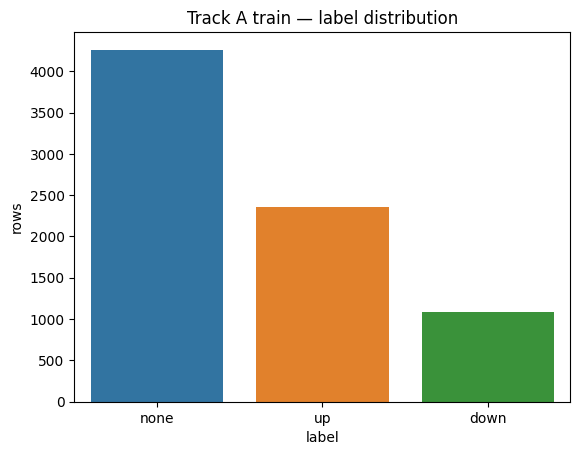

In [5]:
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, legend=False)
plt.title("Track A train — label distribution")
plt.ylabel("rows")
plt.xlabel("label")
plt.show()

**Finding:** `none` ~55%, `up` ~31%, `down` ~14%. Imbalanced — an
"always predict none" baseline scores ~55% accuracy. `down` is the rare,
hardest class.

## 3. Data quality — missing values

In [6]:
train.isna().sum()

id       0
pert     0
gene     0
label    0
dtype: int64

No missing values — the data is clean.

## 4. Scale — unique perturbations and readout genes

In [7]:
pd.DataFrame(
    {
        "train": [train["pert"].nunique(), train["gene"].nunique()],
        "test": [test["pert"].nunique(), test["gene"].nunique()],
    },
    index=["unique perts", "unique genes"],
)

,train,test
unique perts,386,96
unique genes,1570,636


## 5. Train/test overlap — the key finding

Are the perturbations and readout genes in the test set ever seen during
training? If not, the model cannot memorize; it must generalize.

In [8]:
def overlap(train_col, test_col):
    """Return (n test values seen in train, n unique test values)."""
    return len(set(train_col) & set(test_col)), len(set(test_col))

p_hit, p_tot = overlap(train["pert"], test["pert"])
g_hit, g_tot = overlap(train["gene"], test["gene"])
print(f"test perts seen in train: {p_hit}/{p_tot}")
print(f"test genes seen in train: {g_hit}/{g_tot}")

test perts seen in train: 0/96
test genes seen in train: 0/636


**Finding:** zero overlap — every test perturbation *and* every test readout
gene is unseen in training. Lookup/memorization is impossible; the model must
generalize from biological knowledge. This is a strong argument for an
LLM-reasoning approach (Track A).

## 6. How many readout genes per perturbation?

In [9]:
per_pert = train.groupby("pert").size()
per_pert.describe()

count    386.000000
mean      19.961140
std        2.722879
min       15.000000
25%       18.000000
50%       19.000000
75%       21.000000
max       33.000000
dtype: float64

## Summary of findings

- **7,705** train rows (386 perts x 1,570 genes); **1,813** test rows.
- **Class balance:** none 55.3% / up 30.6% / down 14.1% -> baseline to beat ~55%.
- **Clean:** no missing values.
- **Zero train/test overlap** in perts and genes -> must generalize, not memorize.
- **Implication:** the held-out design fits framing the task as LLM reasoning
  over gene biology (Track A), not table lookup.

## Going deeper — GO / functional analysis

This notebook covers the structural EDA. A deeper investigation of the
*predictive signal* (GO annotation of perturbations and targets, the
DE-vs-none decomposition, and the perturbation x target direction interaction)
is written up in the team wiki:

**-> [`knowledge/wiki/findings/track-a-eda.md`](../knowledge/wiki/findings/track-a-eda.md)**

Headline results from that analysis:

- **DE vs none is deliberately hard** — per-perturbation DE-rate is flat
  (~0.45, design-fixed); pairwise functional association predicts DE only
  weakly (AUROC ~0.52).
- **Direction (up/down) is the exploitable signal** — knocking down
  *housekeeping* genes skews targets **up** (~70%), *immune* genes skew them
  **down** (~60%).
- Train vs test perturbations differ in functional emphasis (possible
  distribution shift).

Figures and derived tables: `outputs/track-a-eda/` (gitignored, local).
